# **Thống kê mô tả chất lượng rượu vang đỏ**

## Khai báo thư viện

In [2]:
import pandas as pd
from IPython import display
import matplotlib.pyplot as plt
import seaborn as sns

## Nạp dữ liệu

In [3]:
data_path = "winequality-red.csv"
#data_names = ["fixed acidity", "volatile acidity", "citric acid", "residual sugar"
#              , "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density", "pH"
#              , "sulphates", "alcohol", "quality"]
df_dataset = pd.read_csv(data_path)

## Thống kê mô tả

### Hiển thị số dòng và số cột của dữ liệu

In [4]:
# so dong, so cot cua du lieu
print(f'Số dòng, số cột của dữ liệu: ', df_dataset.shape)

Số dòng, số cột của dữ liệu:  (1599, 12)


**Nhận xét:** Bộ dữ liệu "winequality.csv" có 1599 dòng dữ liệu và 12 cột (12 đặc trưng).

### Hiển thị kiểu dữ liệu

In [5]:
# kieu du lieu cua tung cot
print(f'Kiểu dữ liệu của từng cột:\n',df_dataset.dtypes)

Kiểu dữ liệu của từng cột:
 fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


**Nhận xét:** Ngoại trừ đặc trưng "quality" có tính kiểu dữ liệu số nguyên thì tất cả các đặc trưng còn lại có kiểu dữ liệu số thực. Điều này cho thấy rằng, thông tin trong tập dữ liệu có cùng loại thông tin hay là có tính chất đo lường tương tự nhau. Ngoài ra việc cùng kiểu dữ liệu sẽ giúp việc thống kê mô tả trở nên nhanh hơn, dễ xử lý và hiệu quả hơn đồng thời tăng tính nhất quán, dễ phát hiện lỗi hoặc ngoại lệ

### Hiển thị 5 dòng đầu và 5 dòng cuối của dữ liệu

In [6]:
# hien thi 5 dong dau va 5 dong cuoi 
display.display(df_dataset.head(5))
display.display(df_dataset.tail(5))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,NaN,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


**Nhận xét:** Việc hiển thị 5 dòng đầu và 5 dòng cuối của tập dữ liệu cho phép chúng ta xem tổng quan về bộ dữ liệu mà chúng ta sẽ xử lý, qua đó sẽ có các bước giải pháp tiếp theo để xử lý hiệu quả.

### Hiển thị thông tin chung về dữ liệu

In [7]:
df_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1597 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


**Nhận xét:** Tập dữ liệu có dữ liệu thiếu tại đặc trưng "citric acid", ngoài ra các đặc trưng còn lại thì đẩy đủ.

In [8]:
df_clean = df_dataset.copy() #tạo bản sao

In [9]:
# đổi tên
df_clean.rename(columns={"fixed acidity": "fixed_acidity", "volatile acidity": "volatile_acidity",
                    "citric acid": "citric_acid", "residual sugar": "residual_sugar",
                    "chlorides": "chlorides", "free sulfur dioxide": "free_sulfur_dioxide",
                    "total sulfur dioxide": "total_sulfur_dioxide"}, inplace=True)

### Kiểm tra tính toàn vẹn của dữ liệu

* Kiểm tra giá trị trùng lặp

In [10]:
# Kiểm tra dữ liệu trùng lặp
data_dup = df_clean[df_clean.duplicated(keep=False)]
if not data_dup.empty:
    print('So hang trung nhau: ', data_dup.shape[0])
    display.display(data_dup)
else:
    print('Khong co du lieu trung lap nao.')

So hang trung nhau:  460


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
9,7.5,0.500,0.36,6.1,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
11,7.5,0.500,0.36,6.1,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
22,7.9,0.430,0.21,1.6,0.106,10.0,37.0,0.99660,3.17,0.91,9.5,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1567,7.2,0.695,0.13,2.0,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1579,6.2,0.560,0.09,1.7,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5
1581,6.2,0.560,0.09,1.7,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5
1592,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6


**Nhận xét:** Có 460 hàng trùng nhau lặp nhau, nghĩa là thực chất chỉ có 230 hàng thông tin duy nhất, trong khi tập dữ liệu chỉ có gần 1600 dòng dữ liệu. Sự trùng lặp chiếm khoảng 14,38%, điều này không quá lớn đối với dữ liệu nhưng cũng không phải là nhỏ.

* Kiểm tra giá trị null

In [11]:
# Kiểm tra giá trị thiếu
data_null = df_clean[df_clean.isnull().any(axis=1)]
if not data_null.empty:
    print(f'+ Null data: ', data_null.shape[0])
    display.display(data_null)
    print("Số lượng giá trị null theo từng cột:")
    print(df_clean.isnull().sum())
else: print('No Null data.')


+ Null data:  2


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
1,7.8,0.88,NaN,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
7,7.3,0.65,NaN,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7


Số lượng giá trị null theo từng cột:
fixed_acidity           0
volatile_acidity        0
citric_acid             2
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


**Nhận xét:** Có 2 giá trị thiếu ở cột "citric_acid" tại index 1 và 7. Số lượng giá trị thiếu không đáng kể, có thể xử lý bằng cách xóa dòng dữ liệu có giá trị thiếu hoặc thay thế giá trị thiếu bằng giá trị 0.

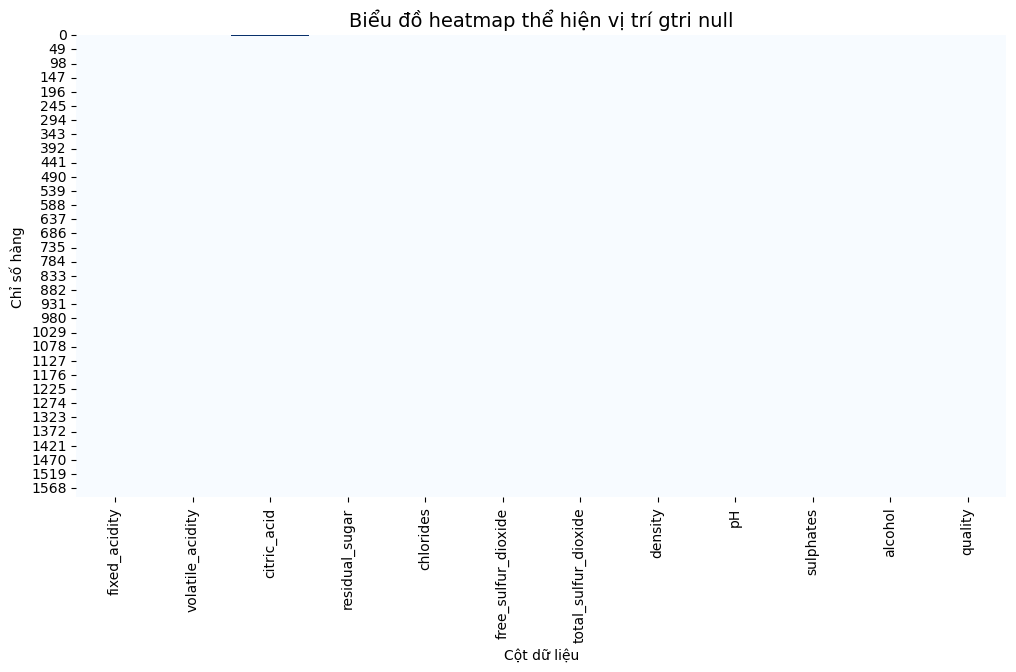

In [12]:
# Cach 2: Bieu do heatmap (ban do nhiet) de xem vi tri null
plt.figure(figsize=(12,6))
sns.heatmap(df_clean.isnull(), cmap = 'Blues', cbar = False)

plt.title('Biểu đồ heatmap thể hiện vị trí gtri null', fontsize = 14)
plt.xlabel('Cột dữ liệu')
plt.ylabel('Chỉ số hàng')
plt.show()

**Nhận xét:** Biểu đồ heatmap trực quan giá trị thiếu cho thấy chỉ có một chút màu xanh tại chỉ số hàng 0 cột citric_acid.

* Xử lý các giá trị trùng lặp

In [13]:
#Xử lý giá trị dup
#data_copy = data_copy.drop_duplicates(keep='first')
df_clean.drop_duplicates(inplace=True)

#Kiem tra lai gtri dup
print(df_clean.duplicated().sum().any())

False


**Nhận xét:** Tiến hành xử lý các giá trị trùng lặp và kiểm tra lại xem tập dữ liệu có còn dữ liệu bị trùng lặp nữa không.

* Xử lý các giá trị null

In [14]:
df_clean = df_clean.fillna(0)
print(df_clean.isnull().sum().any())

False


**Nhận xét:** Tiến hành xử lý các giá trị thiếu và kiểm tra lại xem tập dữ liệu có còn dữ liệu bị thiếu nữa không.

### Hiển thị các tính chất thống kê trên dữ liệu số

In [15]:
description = df_clean.describe().T
display.display(description)

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,1359.0,8.310596,1.736990,4.60000,7.1000,7.9000,9.20000,15.90000
volatile_acidity,1359.0,0.529478,0.183031,0.12000,0.3900,0.5200,0.64000,1.58000
citric_acid,1359.0,0.272333,0.195537,0.00000,0.0900,0.2600,0.43000,1.00000
residual_sugar,1359.0,2.523400,1.352314,0.90000,1.9000,2.2000,2.60000,15.50000
chlorides,1359.0,0.088124,0.049377,0.01200,0.0700,0.0790,0.09100,0.61100
free_sulfur_dioxide,1359.0,15.893304,10.447270,1.00000,7.0000,14.0000,21.00000,72.00000
total_sulfur_dioxide,1359.0,46.825975,33.408946,6.00000,22.0000,38.0000,63.00000,289.00000
density,1359.0,0.996709,0.001869,0.99007,0.9956,0.9967,0.99782,1.00369
pH,1359.0,3.309787,0.155036,2.74000,3.2100,3.3100,3.40000,4.01000
sulphates,1359.0,0.658705,0.170667,0.33000,0.5500,0.6200,0.73000,2.00000


**Nhận xét:** 
* Sau khi xử lý các giá trị trùng lặp và các giá trị bị thiếu thì tập dữ liệu còn lại 1359 dòng dữ liệu.
* "free_sulfur_dioxide" và "total_sulfur_dioxide" có độ lệch chuẩn cao, cho thấy phân bố của chúng rất phân tán, có thể có outlier (giá trị ngoại lai). Ngược lại, "density", "pH", và "sulphates" có độ lệch chuẩn nhỏ, nghĩa là giá trị tập trung quanh trung bình → biến này khá ổn định.
* Hầu hết các đặc đặc trưng có mean ≈ median(50%), cho thấy rằng dữ liệu tương đối đối xứng, tuy nhiên một số biến như "resisual_sugar" hoặc "total_sulfur_dioxide" có mean > median, cho thấy phân bố lệch phải.
* Biến mục tiêu (quality) có min = 3 và max = 8 cho thấy giá trị nằm trong khoảng 3-8, mean = 5.62 và std = 0.82 cho thấy chất lượng rượu tập trung quanh mức trung bình, ít rượu quá tệ hoặc quá tốt


### Hiển thị dữ liệu trên từng tính chất đơn

* **Box and whisker plots**

<Axes: >

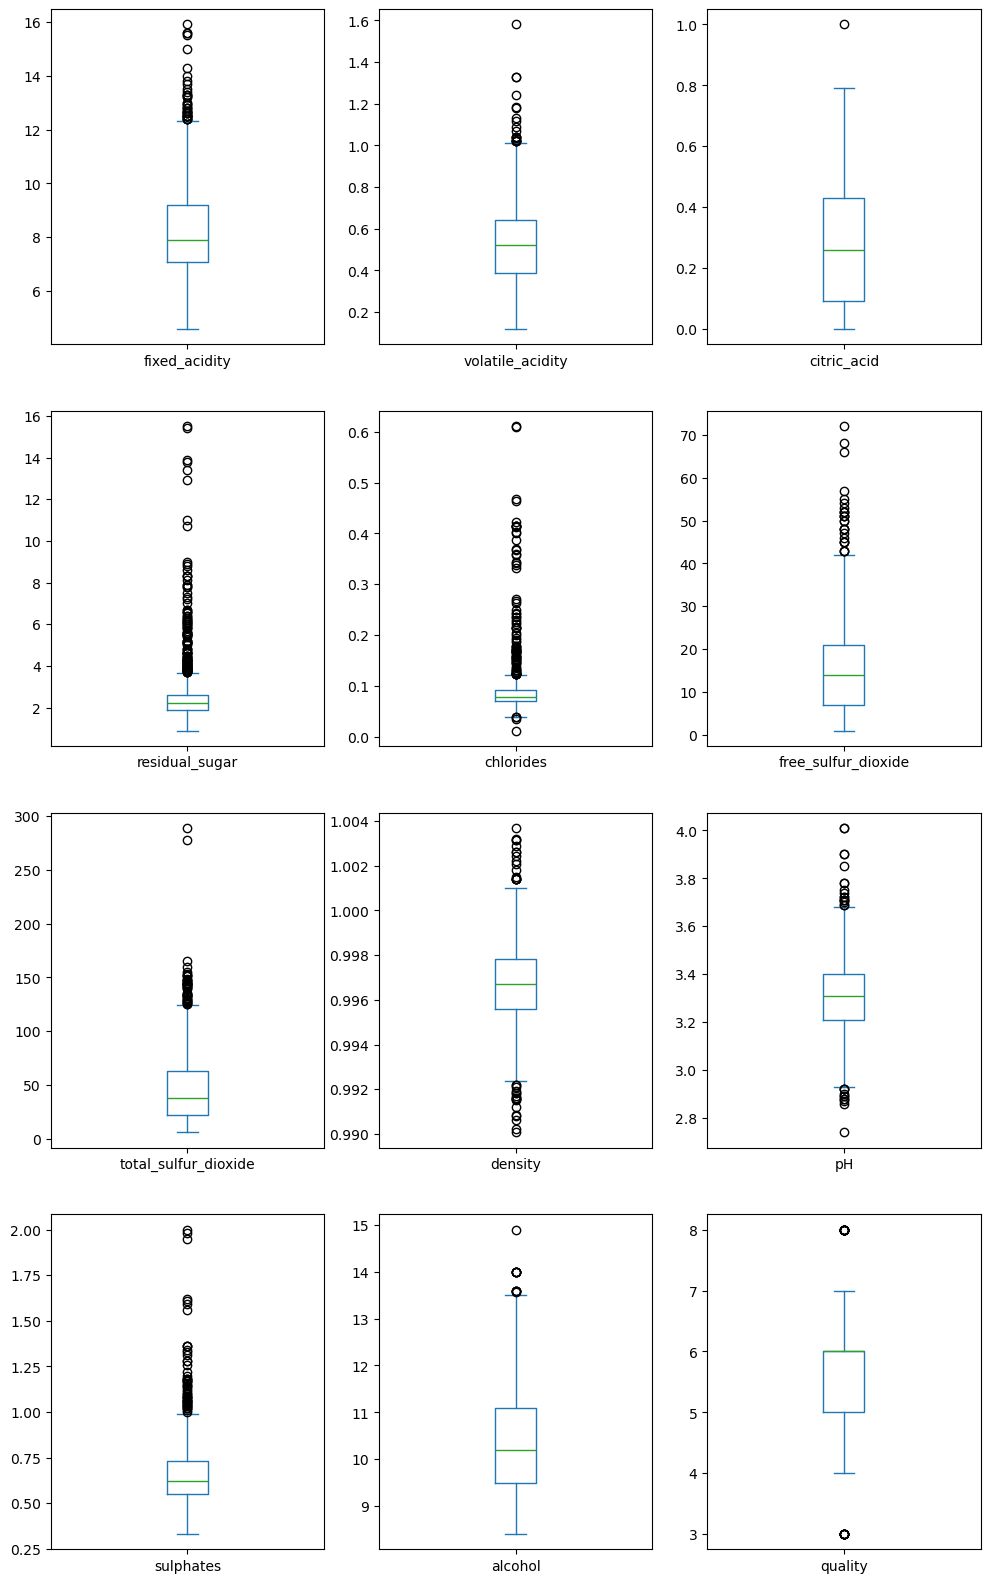

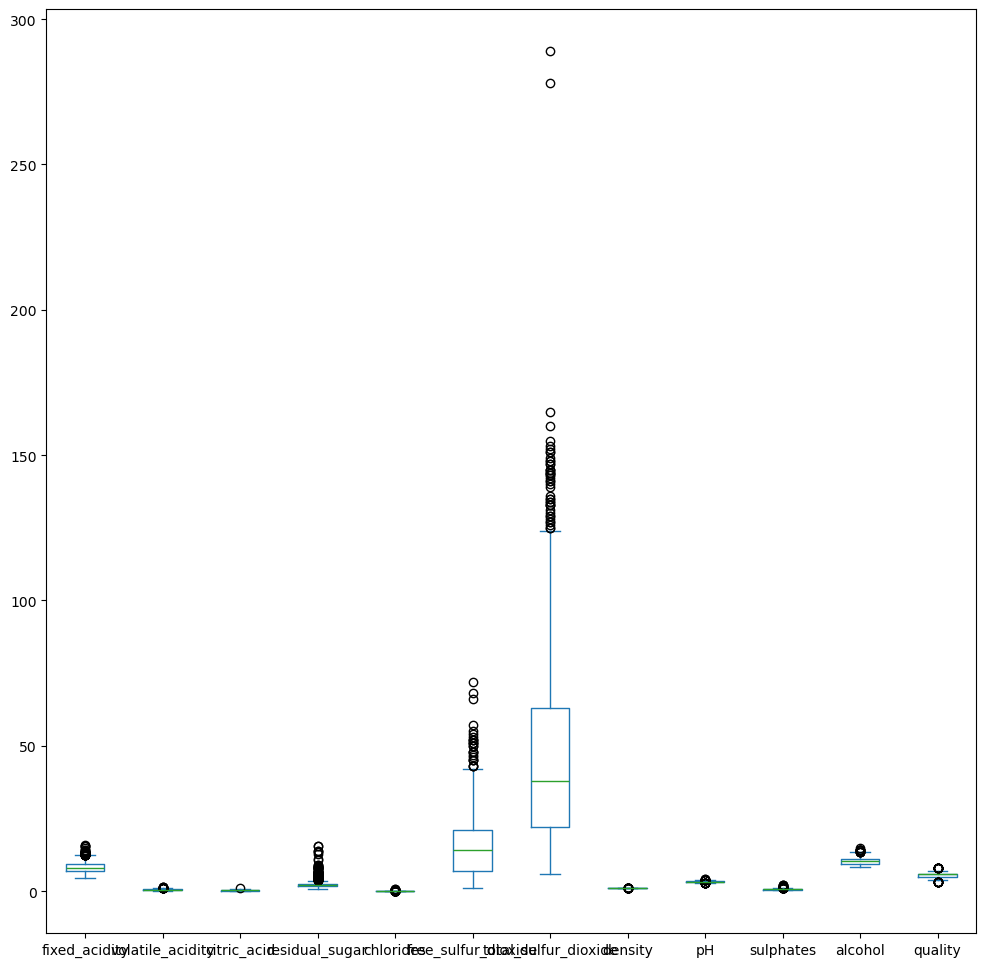

In [16]:
df_clean.plot(kind="box", subplots=True, layout=(4, 3), sharex=False, sharey=False, figsize=(12, 20))
df_clean.plot(kind="box", figsize=(12, 12))

* **Histogram**

array([[<Axes: title={'center': 'fixed_acidity'}>,
        <Axes: title={'center': 'volatile_acidity'}>,
        <Axes: title={'center': 'citric_acid'}>],
       [<Axes: title={'center': 'residual_sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free_sulfur_dioxide'}>],
       [<Axes: title={'center': 'total_sulfur_dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>]], dtype=object)

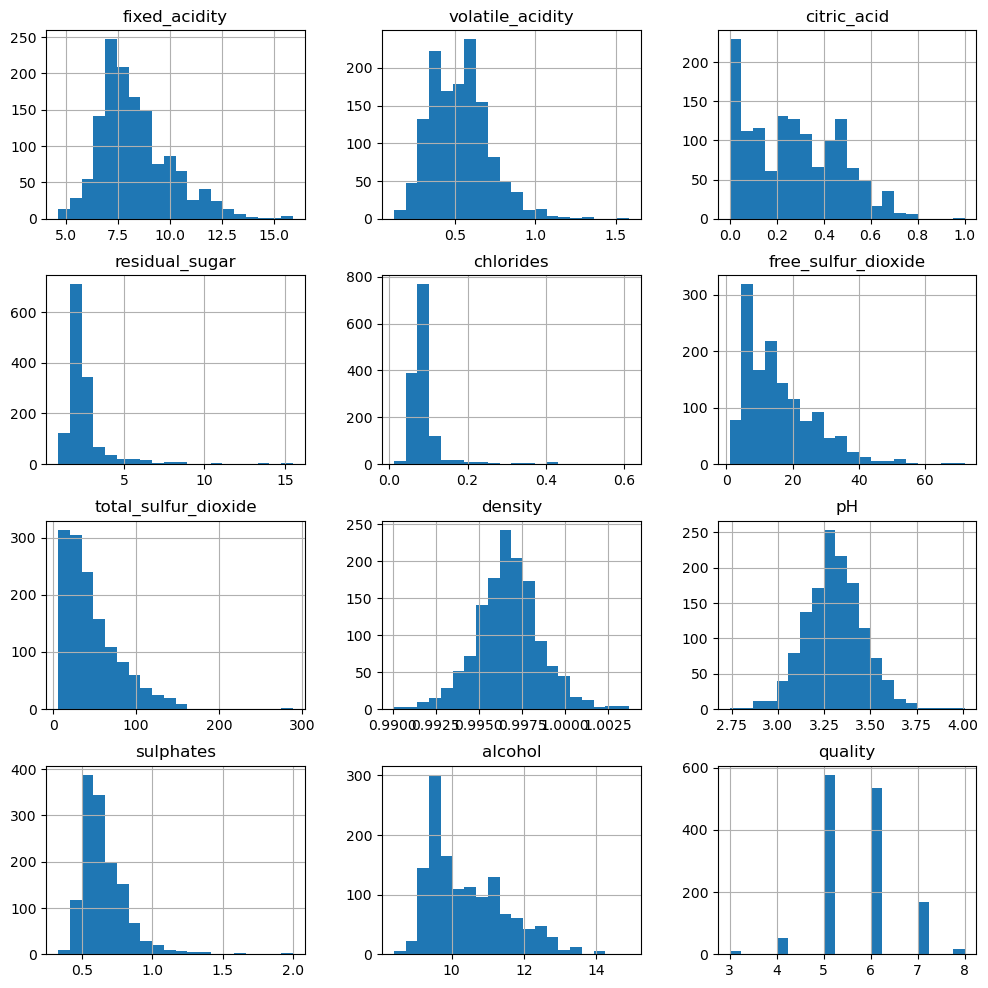

In [17]:
df_clean.hist(figsize=(12, 12), bins= 20, sharex=False, sharey=False)

### Hiển thị nhiều tính chất của dữ liệu

array([[<Axes: xlabel='fixed_acidity', ylabel='fixed_acidity'>,
        <Axes: xlabel='volatile_acidity', ylabel='fixed_acidity'>,
        <Axes: xlabel='citric_acid', ylabel='fixed_acidity'>,
        <Axes: xlabel='residual_sugar', ylabel='fixed_acidity'>,
        <Axes: xlabel='chlorides', ylabel='fixed_acidity'>,
        <Axes: xlabel='free_sulfur_dioxide', ylabel='fixed_acidity'>,
        <Axes: xlabel='total_sulfur_dioxide', ylabel='fixed_acidity'>,
        <Axes: xlabel='density', ylabel='fixed_acidity'>,
        <Axes: xlabel='pH', ylabel='fixed_acidity'>,
        <Axes: xlabel='sulphates', ylabel='fixed_acidity'>,
        <Axes: xlabel='alcohol', ylabel='fixed_acidity'>,
        <Axes: xlabel='quality', ylabel='fixed_acidity'>],
       [<Axes: xlabel='fixed_acidity', ylabel='volatile_acidity'>,
        <Axes: xlabel='volatile_acidity', ylabel='volatile_acidity'>,
        <Axes: xlabel='citric_acid', ylabel='volatile_acidity'>,
        <Axes: xlabel='residual_sugar', ylabel='vol

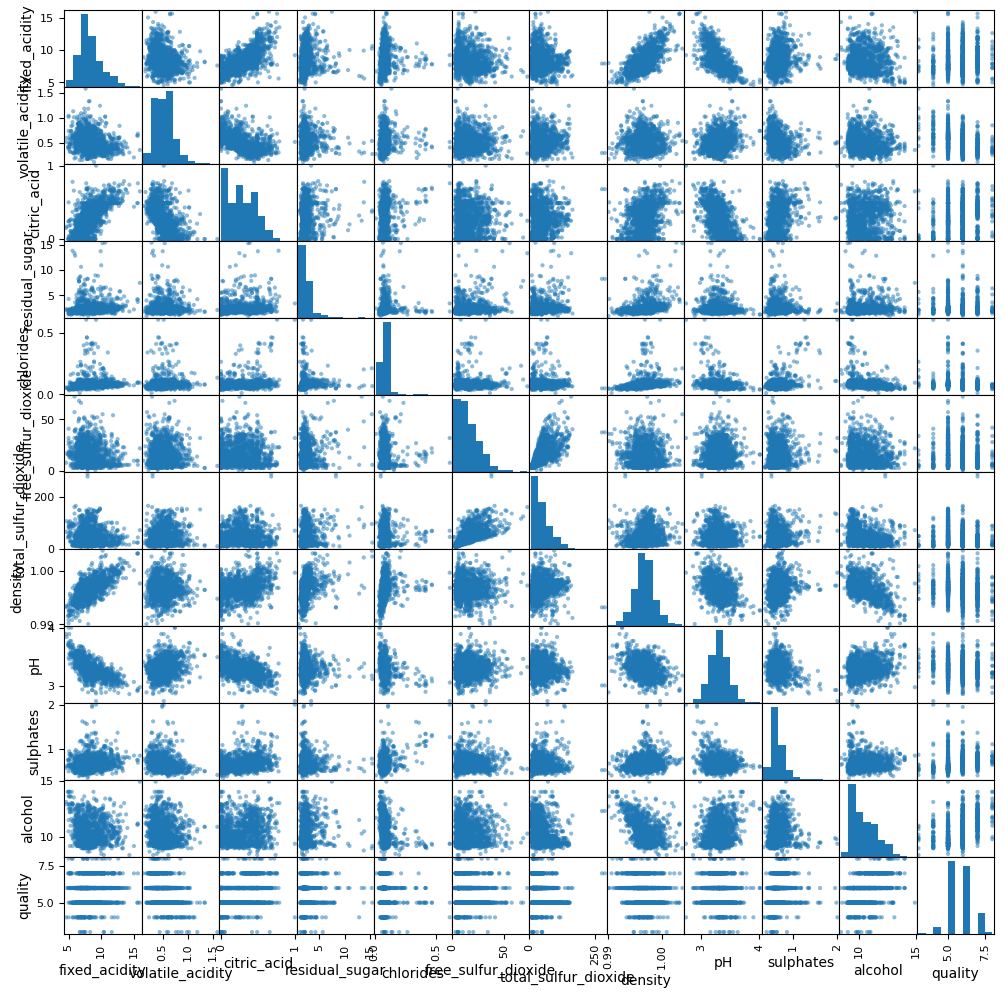

In [18]:
pd.plotting.scatter_matrix(df_clean, figsize=(12, 12))

### Mối tương quan giữa các đặc trưng

In [19]:
correlations = df_clean.corr(method = 'pearson')
display.display(correlations)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
fixed_acidity,1.000000,-0.255124,0.667437,0.111025,0.085886,-0.140580,-0.103777,0.670195,-0.686685,0.190269,-0.061596,0.119024
volatile_acidity,-0.255124,1.000000,-0.551248,-0.002449,0.055154,-0.020945,0.071701,0.023943,0.247111,-0.256948,-0.197812,-0.395214
citric_acid,0.667437,-0.551248,1.000000,0.143892,0.210195,-0.048004,0.047358,0.357962,-0.550310,0.326062,0.105108,0.228057
residual_sugar,0.111025,-0.002449,0.143892,1.000000,0.026656,0.160527,0.201038,0.324522,-0.083143,-0.011837,0.063281,0.013640
chlorides,0.085886,0.055154,0.210195,0.026656,1.000000,0.000749,0.045773,0.193592,-0.270893,0.394557,-0.223824,-0.130988
free_sulfur_dioxide,-0.140580,-0.020945,-0.048004,0.160527,0.000749,1.000000,0.667246,-0.018071,0.056631,0.054126,-0.080125,-0.050463
total_sulfur_dioxide,-0.103777,0.071701,0.047358,0.201038,0.045773,0.667246,1.000000,0.078141,-0.079257,0.035291,-0.217829,-0.177855
density,0.670195,0.023943,0.357962,0.324522,0.193592,-0.018071,0.078141,1.000000,-0.355617,0.146036,-0.504995,-0.184252
pH,-0.686685,0.247111,-0.550310,-0.083143,-0.270893,0.056631,-0.079257,-0.355617,1.000000,-0.214134,0.213418,-0.055245
sulphates,0.190269,-0.256948,0.326062,-0.011837,0.394557,0.054126,0.035291,0.146036,-0.214134,1.000000,0.091621,0.248835


* Biểu đồ heatmap trực quan sự tương quan giữa các biến với nhau

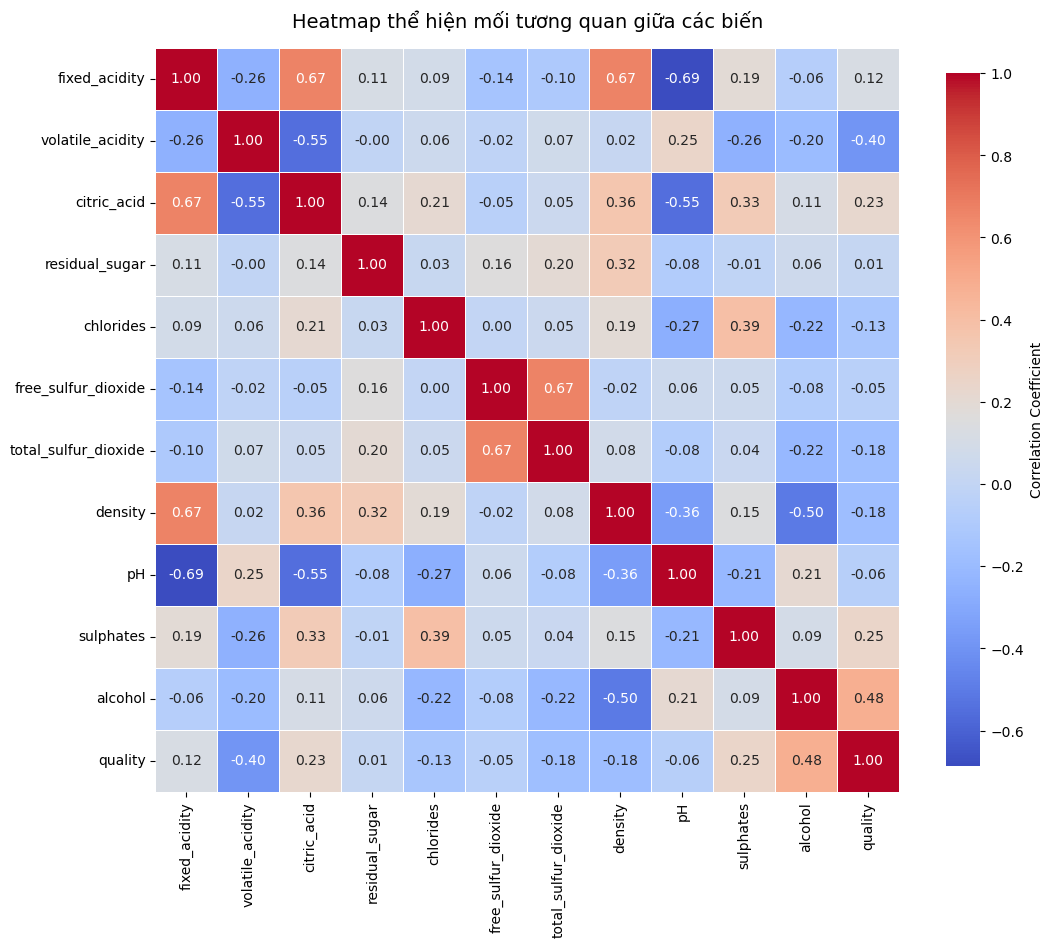

In [21]:
plt.figure(figsize=(12,12))
sns.heatmap(
    correlations,
    annot=True, #hien thi gtri tren cac o
    fmt = ".2f", #lam tron 2 chu so thap phan
    cmap = "coolwarm", #bang mau 
    linewidths=0.5, #khoang cach giua cac o
    square=True, # hien thi o vuong cho dep
    cbar_kws={"shrink": 0.75, "label": "Correlation Coefficient"} #thanh mau ben phai
)
plt.title("Heatmap thể hiện mối tương quan giữa các biến", fontsize = 14, pad=15)
plt.show()